
# Capstone Project: Cardiovascular Risk Prediction
##(Framingham Heart Study)

## 1. Research Question
Can clinical, demographic, and lifestyle health data be used to predict an individual’s risk of experiencing a heart attack (including NSTEMI), and which factors most strongly contribute to that risk?

> **Operationalization with this dataset:**  
The Framingham dataset’s target is **10-year risk of coronary heart disease (CHD)** (`TenYearCHD`).  
We use this as a **proxy for elevated heart attack risk**, aligning with early-detection and prevention goals.

## 2. Data Source
This notebook uses the **Framingham Heart Study dataset (Kaggle version)**, typically provided as a CSV file named `framingham.csv` and containing ~4,200 rows and ~16 columns, including the target `TenYearCHD`.

## 3. Techniques to Be Used
- Logistic Regression (baseline, interpretability-focused)
- Random Forest
- Gradient Boosting
- SVM

**Evaluation metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix  
**Medical emphasis:** minimizing **false negatives** (missed high-risk cases) → focus on **Recall** and threshold tuning.

## 4. Expected Results
A predictive model that identifies individuals at elevated risk with meaningful accuracy, plus interpretable insights about the most influential risk factors.

## 5. Why This Question Is Important
Heart attacks are often difficult to detect early because symptoms can be subtle or misinterpreted. Delayed recognition can lead to severe complications or long-term cardiac damage.

Having recently experienced an NSTEMI myself, I developed a deeper understanding of how critical early detection can be. This experience reinforced the importance of proactive risk assessment rather than reactive treatment.

Early detection can save lives. This project aims to translate machine learning results into clear and interpretable insights that can be acted on by non-technical audiences.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # Added KNN
from sklearn.tree import DecisionTreeClassifier # Added Decision Tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

## Data Read and explore the basic information

In [75]:
# Let's read 'framingham.csv' and save it to panda Datafram df
df = pd.read_csv("data/framingham.csv")
df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [76]:
# Print the shape (number of rows, number of columns) of the DataFrame
print(f"DataFrame shape: {df.shape}")
# Print the list of column names in the DataFrame
print(f"DataFrame columns: {list(df.columns)}")

DataFrame shape: (4240, 16)
DataFrame columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [77]:
# Print a concise summary of the DataFrame, including data types and non-null values
df.info()
# Generate descriptive statistics for all columns, including non-numeric ones, and transpose the result
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


##Data Cleaning & EDA

In [78]:
# Remove duplicate rows.
dup_count = df.duplicated().sum()
if dup_count > 0:
    df.drop_duplicates(inplace=True)
print(f"Removed {dup_count} duplicate rows.")

# Missing values handling
print(f"Missing values summary")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df[missing_df["missing_count"] > 0]

Removed 0 duplicate rows.
Missing values summary


,missing_count,missing_pct
glucose,388,9.150943
education,105,2.476415
BPMeds,53,1.250000
totChol,50,1.179245
cigsPerDay,29,0.683962
BMI,19,0.448113
heartRate,1,0.023585


In [79]:
# Remove rows with too many missing values
row_missing_pct = df.isnull().mean(axis=1) * 100
# set the threshold 30%
threshold_row_missing = 30
rows_before = df.shape[0]
df = df.loc[row_missing_pct <= threshold_row_missing].copy()
print(f"Removed rows with >{threshold_row_missing}% missing: {rows_before - df.shape[0]} rows")
print("After removing high-missing rows:", df.shape)

Removed rows with >30% missing: 0 rows
After removing high-missing rows: (4240, 16)


In [80]:
#In Framingham,
#'education' is often coded 1-4 -> treat as categorical
#'BPMeds' is Binary/Categorical variable (0,1)
# use the Mode (most frequent value).
# .mode() returns a Series, so we take the first element [0].
mode_cols = ['education', 'BPMeds']

for col in mode_cols:
    if col in df.columns:
        # Calculate mode and fill
        col_mode = df[col].mode()[0]
        df[col] = df[col].fillna(col_mode)

        # Convert to category for the model
        df[col] = df[col].astype('category')

#If smoker is 0, cigsPerDay must be 0
df.loc[(df['currentSmoker'] == 0) & (df['cigsPerDay'].isnull()), 'cigsPerDay'] = 0

# Handle remaining columns (Numerical Imputation)
df = df.fillna(df.median(numeric_only=True))

# Final Verification
print("Missing values count per column:")
print(df.isnull().sum())

print("\nData type of 'education' column:")
print(df['education'].dtype)

Missing values count per column:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Data type of 'education' column:
category


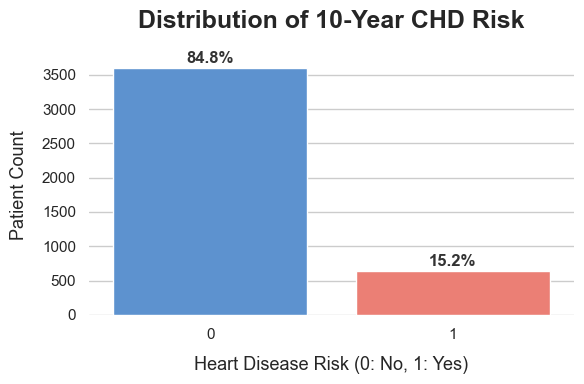

In [81]:
# Set the visual theme for a clean, professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# Define a custom color palette
# Soft Blue for 'No Risk' (0) and Coral for 'Risk' (1)
custom_palette = ['#4A90E2', '#FF6F61']

# Create the count plot
ax = sns.countplot(x='TenYearCHD', data=df, hue='TenYearCHD',
                   palette=custom_palette, legend=False)

# Enhance titles and axis labels for clarity
plt.title('Distribution of 10-Year CHD Risk', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Heart Disease Risk (0: No, 1: Yes)', fontsize=13, labelpad=10)
plt.ylabel('Patient Count', fontsize=13, labelpad=10)

# Add percentage annotations on top of each bar
# This explicitly highlights the class imbalance for the audience
total_count = len(df)
for p in ax.patches:
    # Calculate percentage of the total
    percentage = f'{100 * p.get_height() / total_count:.1f}%'

    # Position the text at the center (x) and slightly above the bar (y)
    x_coord = p.get_x() + p.get_width() / 2
    y_coord = p.get_height() + 30

    ax.annotate(percentage, (x_coord, y_coord), ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='#333333')

# 6. Remove unnecessary chart borders (despining) for a modern look
sns.despine(left=True, bottom=True)

# 7. Adjust layout to prevent clipping of labels
plt.tight_layout()
plt.show()


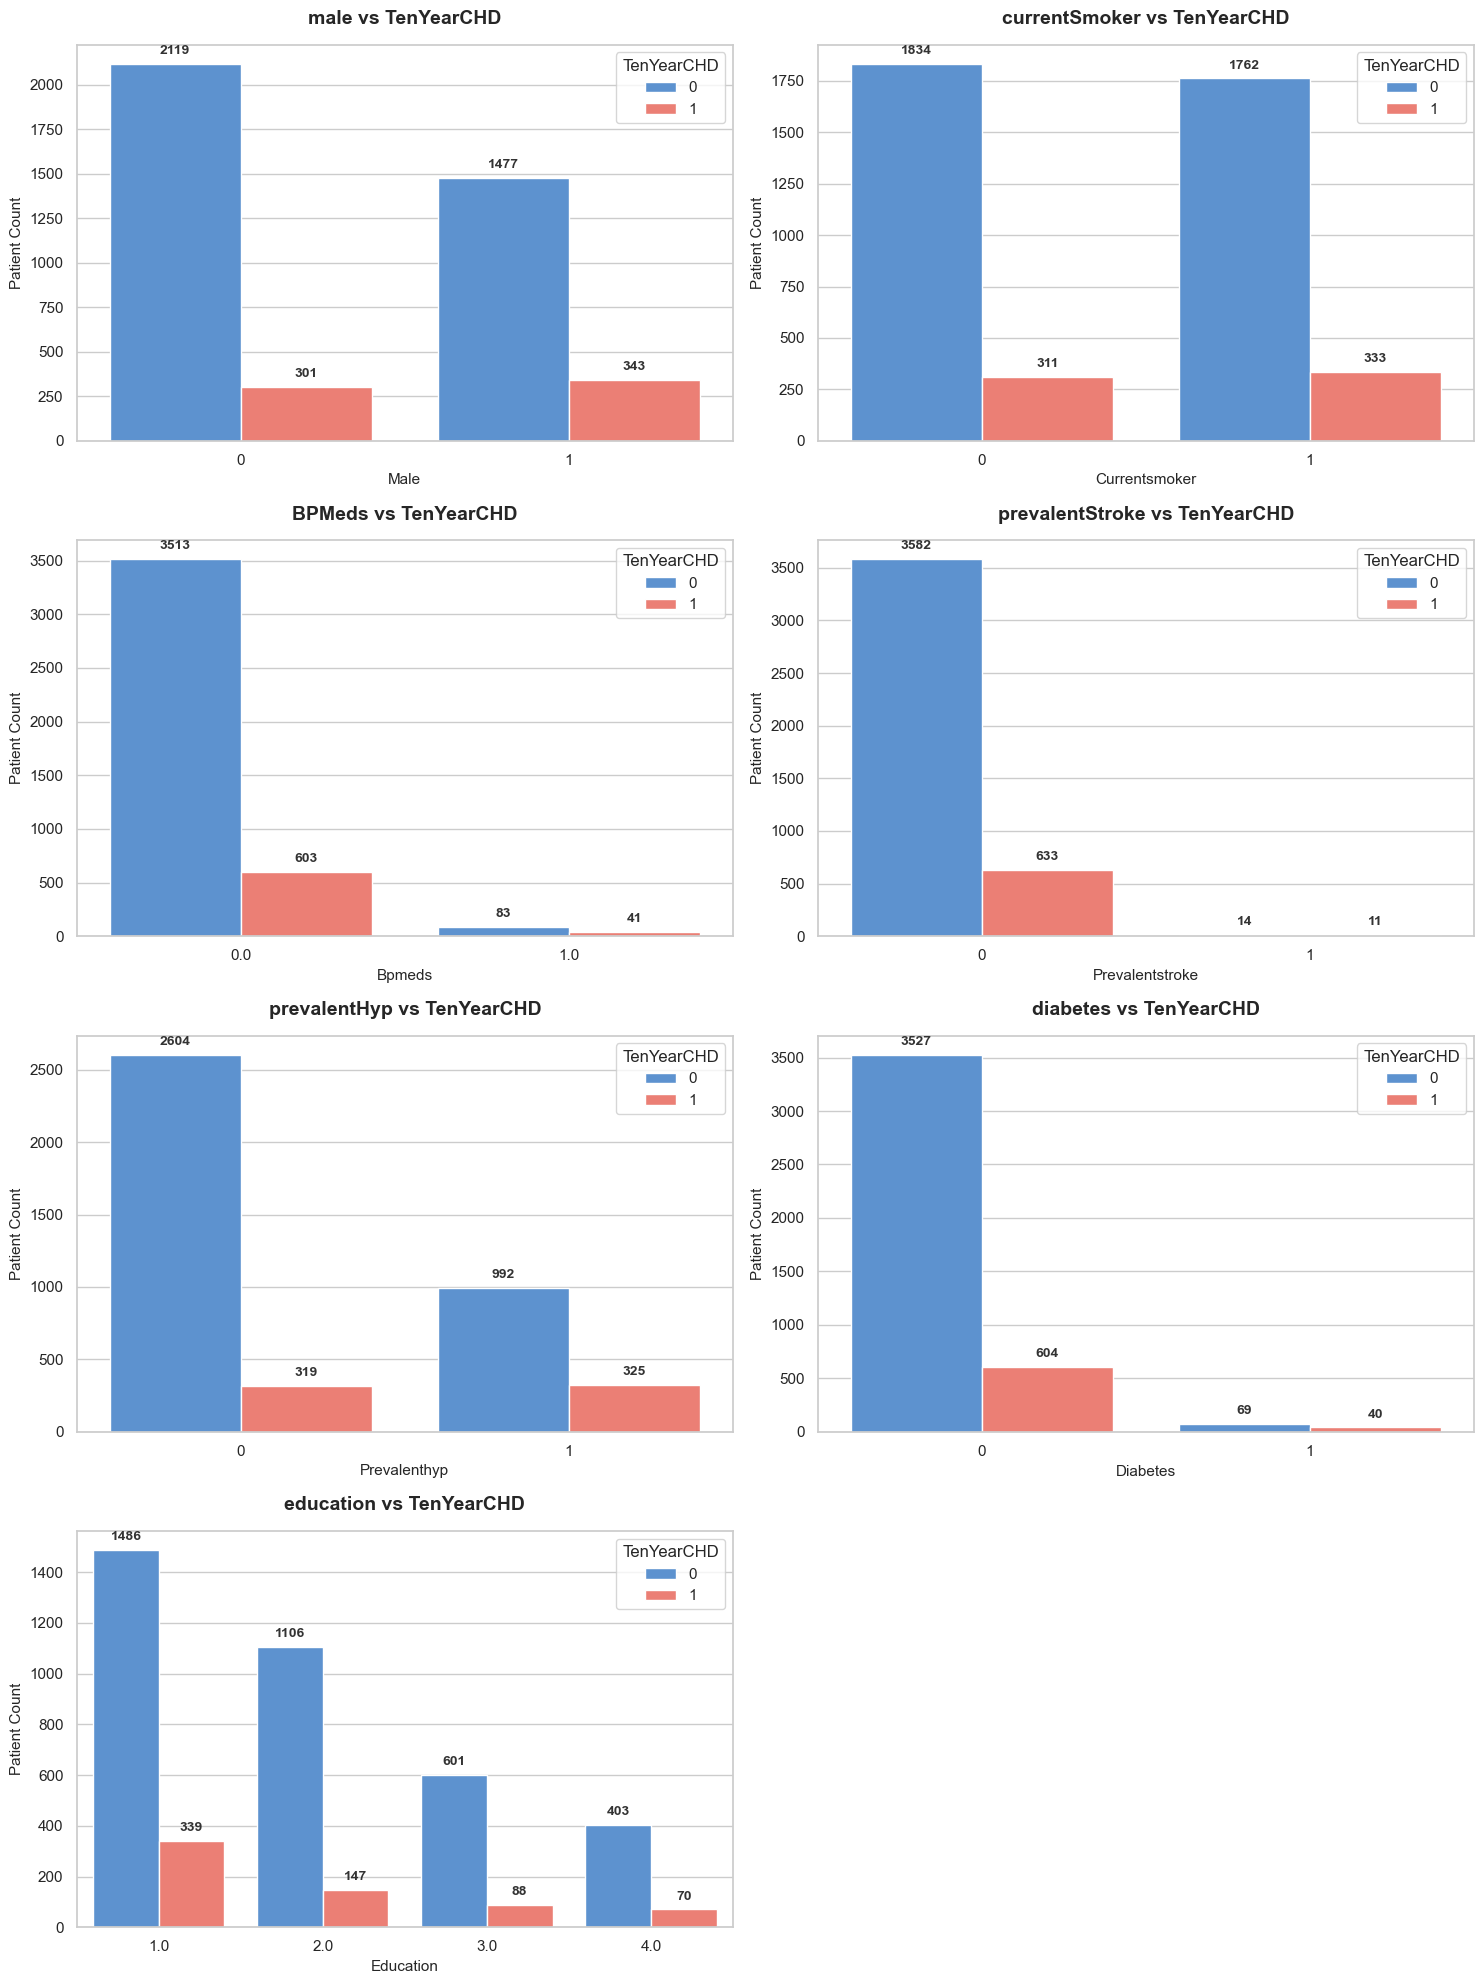

In [82]:
target_col = "TenYearCHD"
# Categorical/binary variables vs target
cat_candidates = ["male","currentSmoker","BPMeds","prevalentStroke","prevalentHyp","diabetes","education"]
cat_cols = [c for c in cat_candidates if c in df.columns]

# Calculate the number of rows needed for a 2-column grid
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

# Set the visual theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

# Custom palette: Blue for 'No Risk', Coral for 'Risk'
custom_palette = ['#4A90E2', '#FF6F61']

# 3. Iterate through each categorical column and create plots
for i, col in enumerate(cat_cols):
    # Create the countplot on the specific subplot axis
    ax = sns.countplot(
        x=col,
        hue=target_col,
        data=df,
        palette=custom_palette,
        ax=axes[i]
    )

    # Set titles and labels
    axes[i].set_title(f'{col} vs {target_col}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(col.capitalize(), fontsize=11)
    axes[i].set_ylabel('Patient Count', fontsize=11)

    # Add percentage annotations on top of each bar within the subplot
    # This helps compare the risk ratio within each category
    group_counts = df.groupby(col, observed=True)[target_col].count()
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Only annotate bars with values
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=10, fontweight='semibold', color='#333333',
                        xytext=(0, 5), textcoords='offset points')

# 4. Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Final layout adjustments
plt.tight_layout()
plt.show()

In [83]:
# Key numeric columns
num_candidates = ["age","totChol","sysBP","diaBP","BMI","heartRate","glucose","cigsPerDay"]
num_cols = [c for c in num_candidates if c in df.columns]

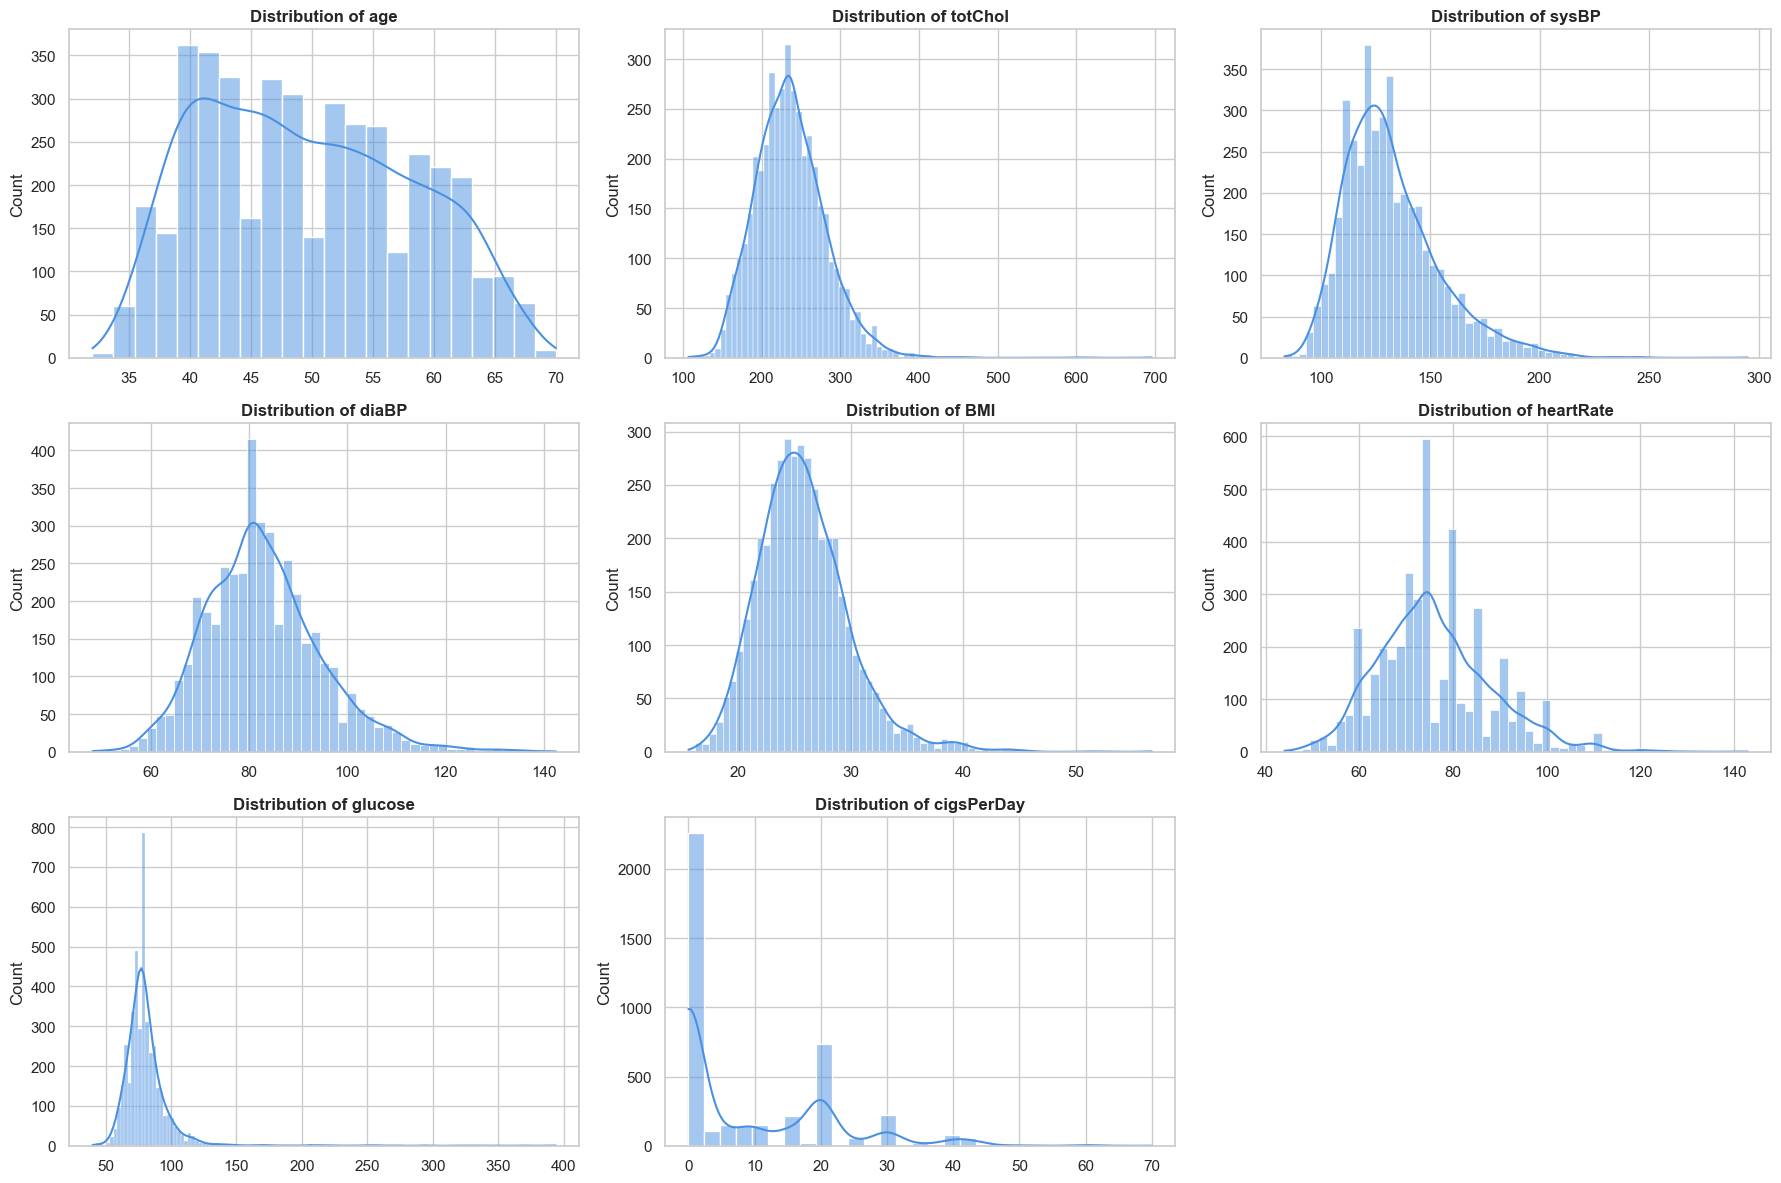

In [84]:
# Numeerical Distributions
# Set up the grid
fig, axes = plt.subplots(math.ceil(len(num_cols)/3), 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # KDE (Kernel Density Estimate) shows the smooth shape of the distribution
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4A90E2')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

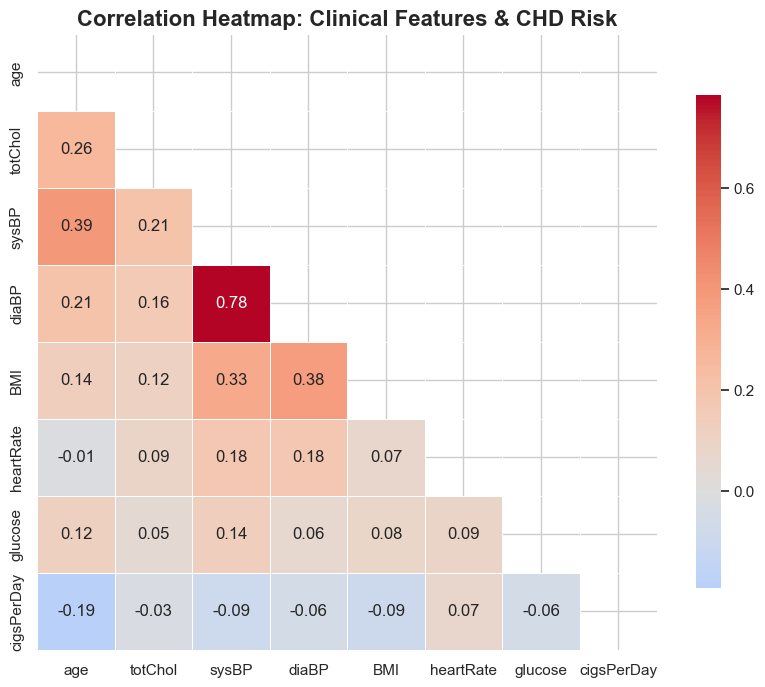

In [85]:
# Correlation Matrix only for numerical columns
corr_matrix = df[num_cols].corr()

# Set up the figure
plt.figure(figsize=(10, 8))

# Create a mask to hide the upper triangle (redundant information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap: Clinical Features & CHD Risk', fontsize=16, fontweight='bold')
plt.show()

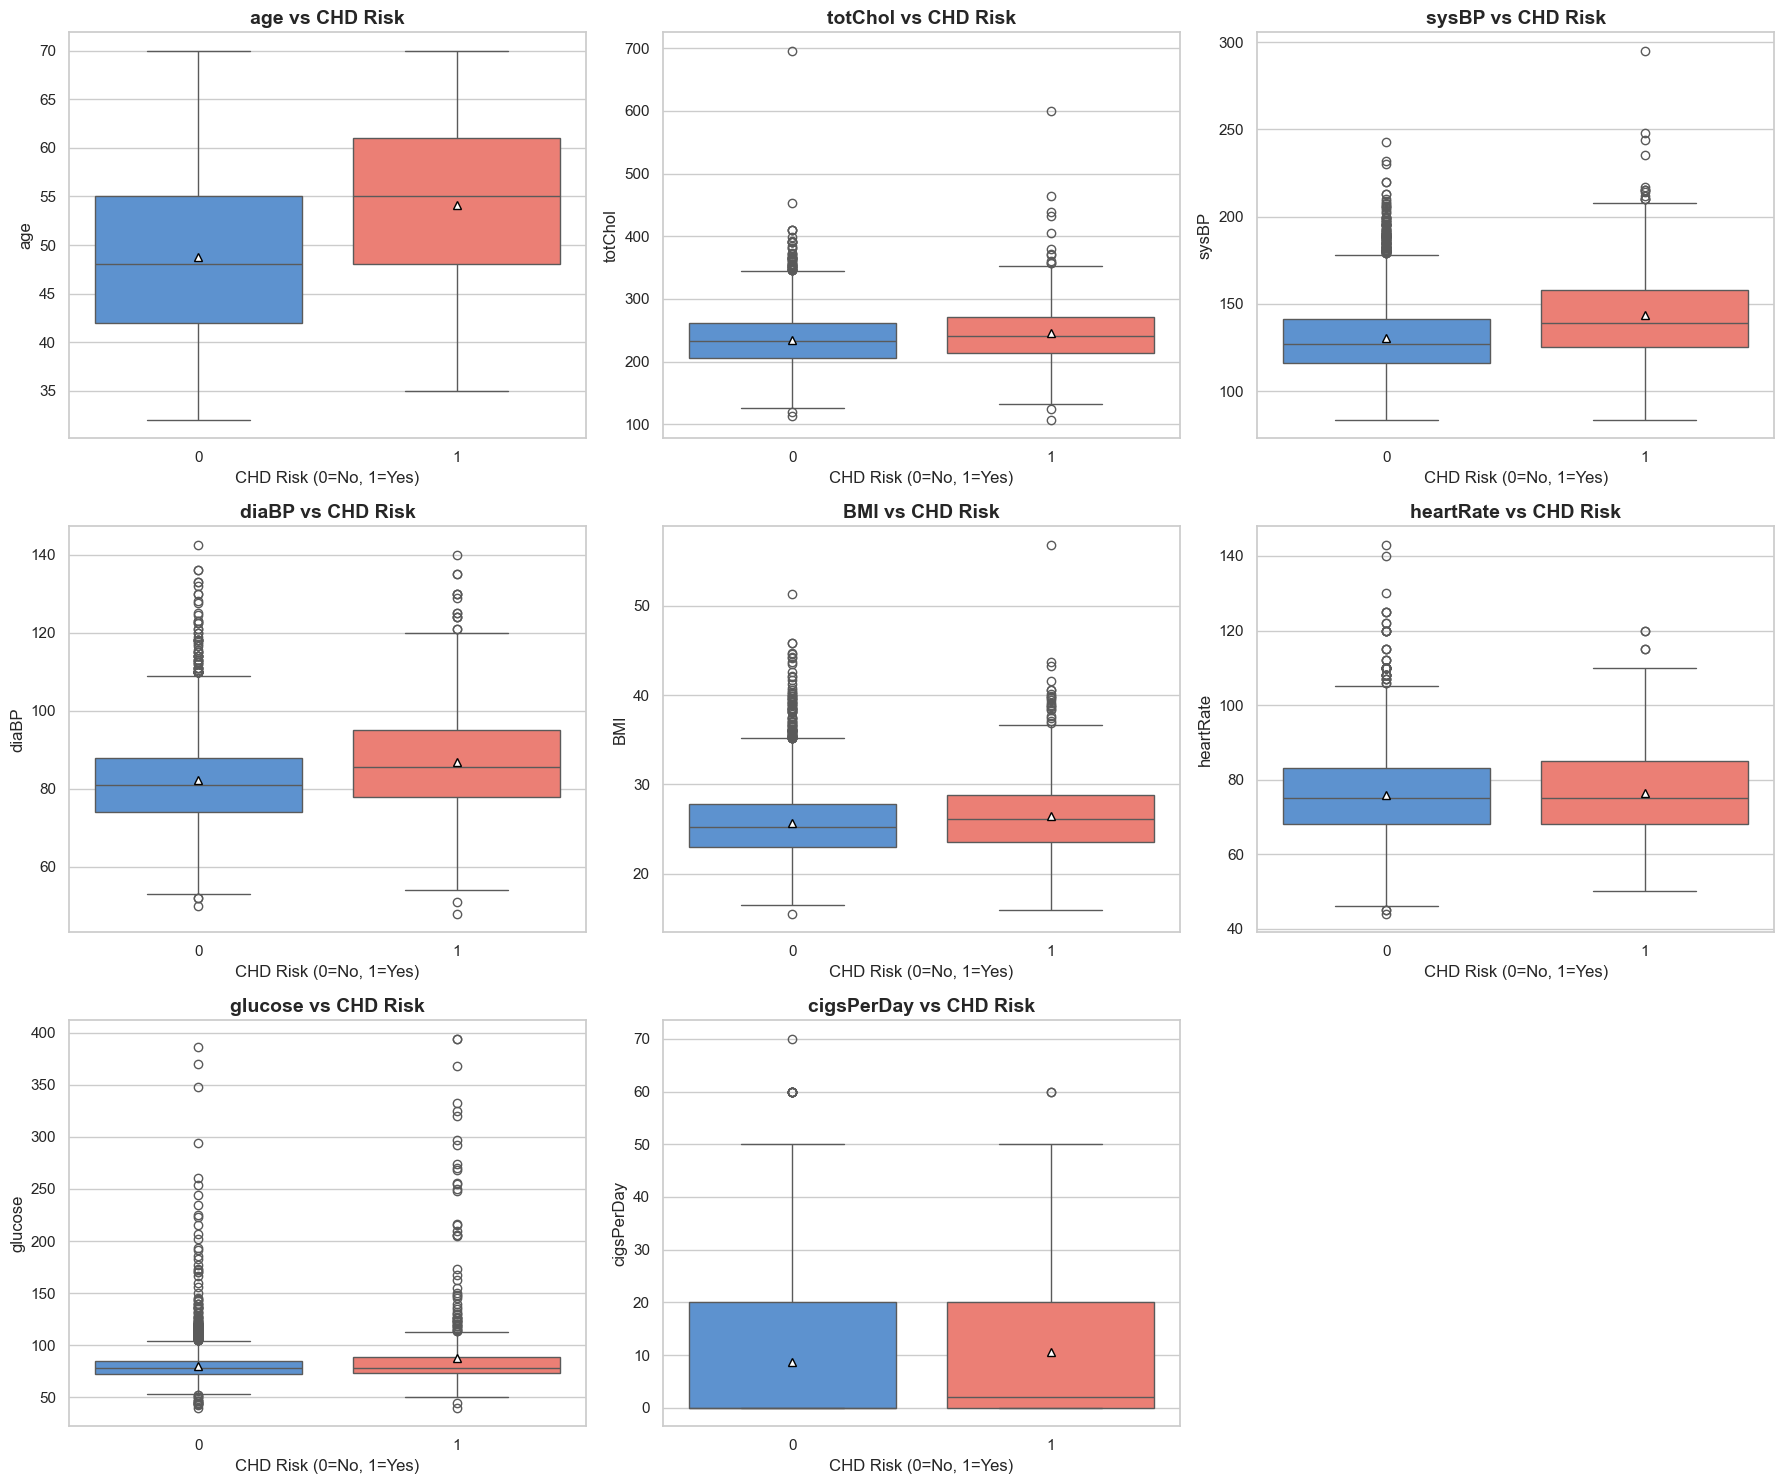

In [86]:
num_plots = len(num_cols)
cols_per_row = 3
rows = math.ceil(num_plots / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 5))
axes = axes.flatten()

# Custom palette for the groups
custom_palette = ['#4A90E2', '#FF6F61']

# 5. Generate Box Plots
for i, col in enumerate(num_cols):
    sns.boxplot(
        x=target_col,
        y=col,
        data=df,
        ax=axes[i],
        hue=target_col,
        palette=custom_palette,
        legend=False,
        showmeans=True, # Shows the mean as a small triangle
        meanprops={"markerfacecolor":"white", "markeredgecolor":"black"}
    )

    axes[i].set_title(f'{col} vs CHD Risk', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('CHD Risk (0=No, 1=Yes)', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Box plots were utilized to assess the distributive differences in clinical biomarkers between CHD-positive and CHD-negative groups. Notably, the Systolic Blood Pressure (sysBP) and Age show the most distinct separation, suggesting they are high-impact features for the predictive model.

## Outlier & Scaling
To address potential bias from outliers in clinical markers such as Glucose and Systolic BP, a Log Transformation and Robust Scaling were implemented. This approach ensures the model remains sensitive to high-risk patients while preventing extreme values from distorting the global weight coefficients

,feature,outlier_count,outlier_pct,lower_bound,upper_bound
6,glucose,262,6.179245,52.500,104.500
2,sysBP,126,2.971698,76.500,184.500
4,BMI,97,2.287736,15.645,35.465
3,diaBP,77,1.816038,52.500,112.500
5,heartRate,76,1.792453,45.500,105.500
1,totChol,57,1.344340,122.000,346.000
7,cigsPerDay,12,0.283019,-30.000,50.000
0,age,0,0.000000,21.000,77.000


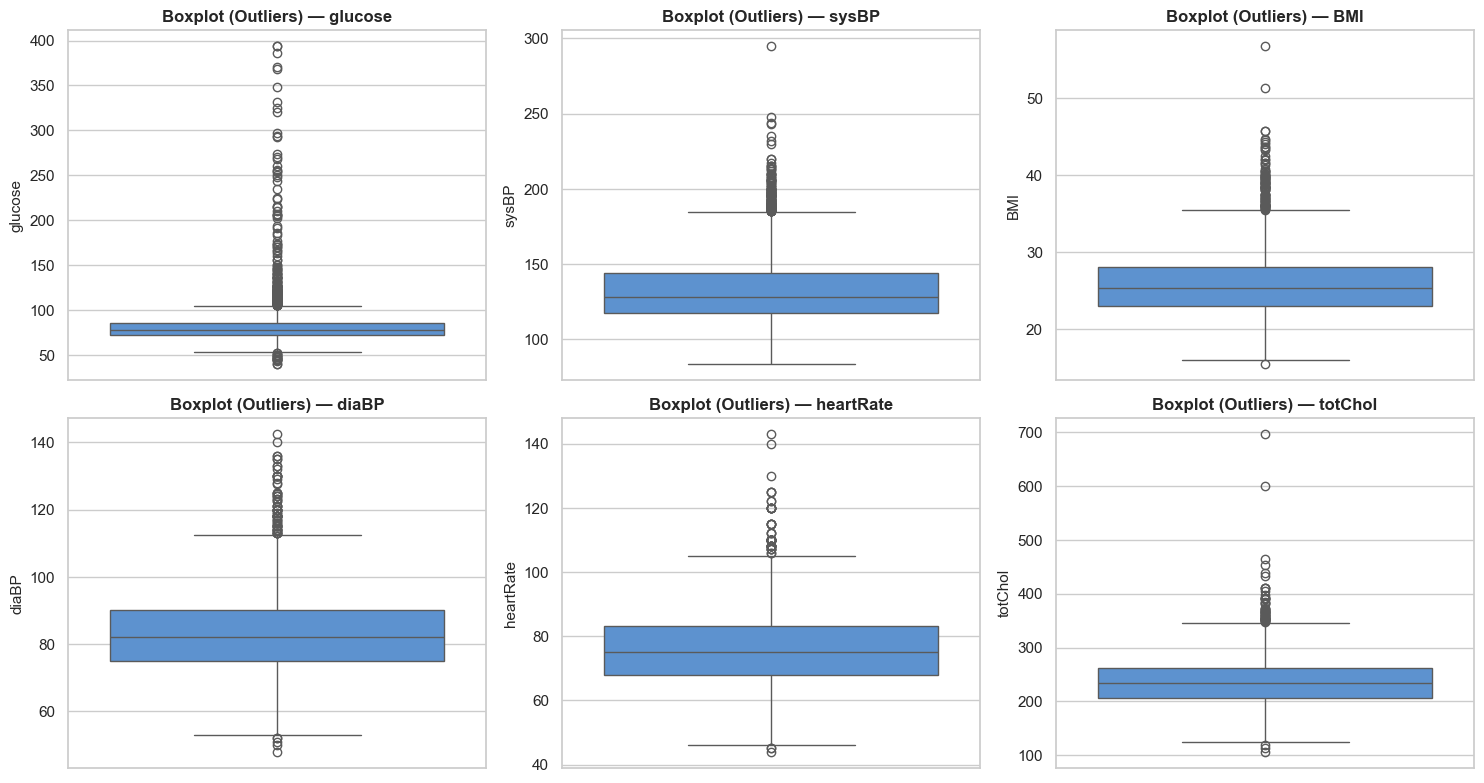

In [ ]:
# Outliers Analysis (IQR)
# - Identify anomalies per numeric feature
# - Visualize with boxplots

def iqr_outlier_summary(df_num, cols):
    rows = []
    for col in cols:
        x = df_num[col].dropna()
        if x.nunique() < 5:
            continue
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((df_num[col] < lower) | (df_num[col] > upper)).sum()
        rows.append({
            "feature": col,
            "outlier_count": int(outliers),
            "outlier_pct": float(outliers) / len(df_num) * 100,
            "lower_bound": float(lower),
            "upper_bound": float(upper)
        })
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

outlier_df = iqr_outlier_summary(df, num_cols)
display(outlier_df.head(15))

# Boxplots for top outlier features
top_features = outlier_df["feature"].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#4A90E2')
    axes[i].set_title(f"Boxplot (Outliers) — {col}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=11)

plt.tight_layout()
plt.show()

In [91]:
# Outlier Handling (Winsorization / Clipping)
# - Clip extreme values to IQR bounds (or percentile-based)
# - Keeps rows while reducing undue model influence


df_clip = df.copy()

clip_features = outlier_df.query("outlier_pct > 1")["feature"].tolist()
print("Clipping features:", clip_features)

for col in clip_features:
    q1, q3 = df_clip[col].quantile(0.25), df_clip[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clip[col] = df_clip[col].clip(lower, upper)
print("Outlier clipping complete. Example stats:")
display(df_clip[clip_features].describe().T.head(10))

# The df_clip now contains the winsorized values for the features with significant outliers. We can proceed with feature engineering and model training using df_clip to potentially improve model performance by reducing the influence of extreme values.
df = df_clip.copy()

Clipping features: ['glucose', 'sysBP', 'BMI', 'diaBP', 'heartRate', 'totChol']
Outlier clipping complete. Example stats:


,count,mean,std,min,25%,50%,75%,max
glucose,4240.0,79.450472,11.453158,52.500,72.0000,78.0,85.0000,104.500
sysBP,4240.0,131.915684,20.642860,83.500,117.0000,128.0,144.0000,184.500
BMI,4240.0,25.714098,3.787978,15.645,23.0775,25.4,28.0325,35.465
diaBP,4240.0,82.743042,11.404757,52.500,75.0000,82.0,90.0000,112.500
heartRate,4240.0,75.750708,11.622274,45.500,68.0000,75.0,83.0000,105.500
totChol,4240.0,236.170047,42.299175,122.000,206.0000,234.0,262.0000,346.000


In [92]:
df['glucose'] = np.log1p(df['glucose'])
df['sysBP'] = np.log1p(df['sysBP'])

# Winsorization (Capping) for totChol and BMI
# This handles extreme extremes that are likely data entry errors
for col in ['totChol', 'BMI']:
    upper_limit = df[col].quantile(0.99) # Cap at 99th percentile
    lower_limit = df[col].quantile(0.01) # Cap at 1st percentile
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

# Robust Scaling
# RobustScaler is ideal here because it scales data based on the Interquartile Range (IQR),
# ensuring that any remaining outliers do NOT squash the rest of the data.
numerical_cols = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose','cigsPerDay']

numeric_transformer = Pipeline(
    steps=[("scaler", RobustScaler())
])

## Feature Engineering
While the dataset doesn't have a "years smoked" column, we can create a proxy for smoking intensity. We can also bin cigsPerDay into categories like "Non-smoker," "Light," "Moderate," and "Heavy" to capture non-linear risks.

Now that we have categorical features like education and our new smoke_category, we must convert them into a format the machine learning model can understand (1s and 0s).

In [93]:
def smoke_intensity(cigs):
    if cigs == 0: return 'None'
    elif cigs <= 10: return 'Light'
    elif cigs <= 20: return 'Moderate'
    else: return 'Heavy'

df['smoke_category'] = df['cigsPerDay'].apply(smoke_intensity)
df.drop(columns=['cigsPerDay'], inplace=True)

In [94]:
cat_features = ["male","currentSmoker","smoke_category", "BPMeds",
                  "prevalentStroke","prevalentHyp","diabetes","education"]
for col in cat_features:
    if col in df.columns:
        # Convert to category for the model
        df[col] = df[col].astype('category')

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [95]:
target_col = "TenYearCHD"
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

In [96]:
# The final categorial columns and numbericall columns
categorical_cols = []
numerical_cols = []

for col in X.columns:
    if X[col].dtype == "category":
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print(f"Categorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

Categorical Columns: ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'smoke_category']
Numerical Columns: ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [97]:
# Split data into train/test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [98]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=4000, class_weight="balanced", random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=1),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced", n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(probability=True, class_weight="balanced", random_state=42)
}

## Model Training & Evaluation

Train all models and evaluate on test set.

**Evaluation metrics:** Accuracy, Precision, Recall, F1, ROC-AUC  
**Medical focus:** Recall is prioritized to minimize false negatives (missed high-risk patients)

In [105]:

def evaluate(name, pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

pipelines = {}
rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor),
                          ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    rows.append(evaluate(name, pipe, X_test, y_test))

results_df = pd.DataFrame(rows).sort_values(by="ROC-AUC", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.670991,0.251656,0.589147,0.352668,0.698095
5,SVM (RBF Kernel),0.668632,0.232394,0.511628,0.319613,0.659076
4,Gradient Boosting,0.831368,0.266667,0.062016,0.100629,0.655928
3,Random Forest,0.847877,0.500000,0.031008,0.058394,0.641492
1,K-Nearest Neighbors,0.821934,0.107143,0.023256,0.038217,0.556102
2,Decision Tree,0.741745,0.218750,0.271318,0.242215,0.548733


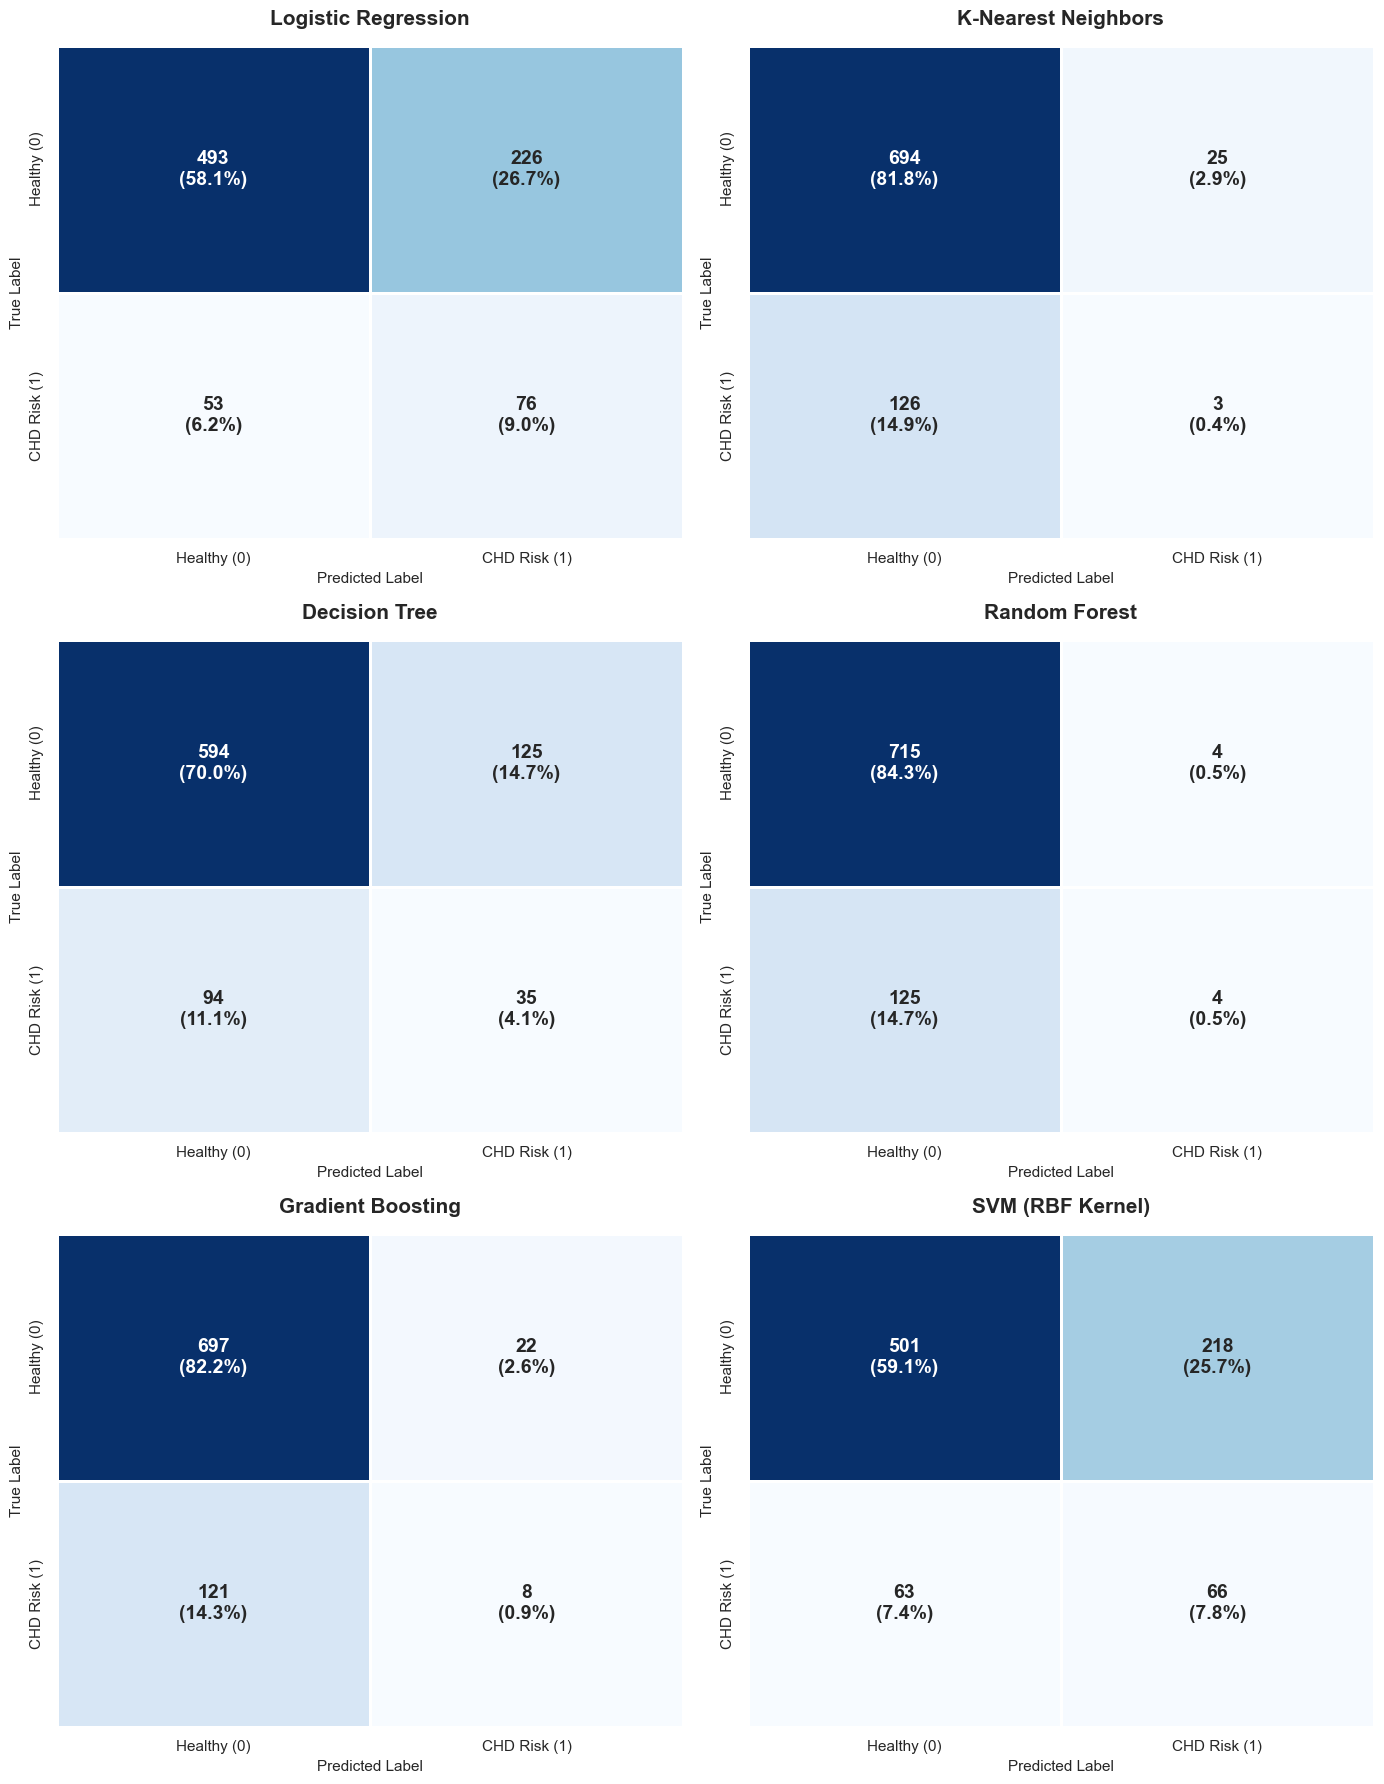

In [106]:


# 1. Setup the grid
num_models = len(pipelines)
cols_per_row = 2
rows = math.ceil(num_models / cols_per_row)

sns.set_theme(style="white")
fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, rows * 6))
axes = axes.flatten()

# 2. Iterate through each model
for i, (name, pipe) in enumerate(pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Calculate percentages relative to the total number of samples
    # Flatten the matrix to calculate, then reshape back
    cm_percent = cm.astype('float') / cm.sum()

    # Create combined labels (Count + Percentage)
    # TN, FP, FN, TP
    labels = (np.array([f"{count}\n({percent:.1%})"
              for count, percent in zip(cm.flatten(), cm_percent.flatten())])
             ).reshape(2, 2)

    # 3. Plotting the heatmap
    sns.heatmap(
        cm,
        annot=labels, # Use our custom combined labels
        fmt="",       # Necessary when passing string labels to annot
        cmap="Blues",
        cbar=False,
        ax=axes[i],
        annot_kws={"size": 14, "fontweight": "bold"},
        linewidths=1,
        linecolor='white'
    )

    # 4. Titles and labels
    axes[i].set_title(f"{name}", fontsize=15, fontweight='bold', pad=15)
    axes[i].set_xticklabels(['Healthy (0)', 'CHD Risk (1)'])
    axes[i].set_yticklabels(['Healthy (0)', 'CHD Risk (1)'], va='center')
    axes[i].set_xlabel('Predicted Label', fontsize=11)
    axes[i].set_ylabel('True Label', fontsize=11)

# Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [107]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor),
                          ("model", model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "Model": name,
        "CV Accuracy (mean)": scores["test_accuracy"].mean(),
        "CV Precision (mean)": scores["test_precision"].mean(),
        "CV Recall (mean)": scores["test_recall"].mean(),
        "CV F1 (mean)": scores["test_f1"].mean(),
        "CV ROC-AUC (mean)": scores["test_roc_auc"].mean(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by="CV ROC-AUC (mean)", ascending=False)
cv_results_df


,Model,CV Accuracy (mean),CV Precision (mean),CV Recall (mean),CV F1 (mean),CV ROC-AUC (mean)
0,Logistic Regression,0.666981,0.265107,0.672299,0.380186,0.720905
5,SVM (RBF Kernel),0.688208,0.263827,0.588457,0.364289,0.694831
3,Random Forest,0.850236,0.630556,0.029494,0.055920,0.692449
4,Gradient Boosting,0.845283,0.449511,0.077653,0.132220,0.688646
1,K-Nearest Neighbors,0.836085,0.319010,0.068338,0.112484,0.603418
2,Decision Tree,0.762028,0.226860,0.236071,0.231059,0.546151


In [108]:

# Threshold tuning to reduce false negatives (medical emphasis)
best_model_name = results_df.iloc[0]["Model"]
best_pipe = pipelines[best_model_name]
print("Best model by ROC-AUC:", best_model_name)

y_proba = best_pipe.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.10, 0.91, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "false_negatives": cm[1,0],
        "false_positives": cm[0,1],
    })

thresh_df = pd.DataFrame(rows)
thresh_df


Best model by ROC-AUC: Logistic Regression


,threshold,precision,recall,f1,false_negatives,false_positives
0,0.10,0.153110,0.992248,0.265285,1,708
1,0.15,0.161209,0.992248,0.277356,1,666
2,0.20,0.169631,0.961240,0.288372,5,607
3,0.25,0.181126,0.922481,0.302799,10,538
4,0.30,0.193548,0.883721,0.317549,15,475
5,0.35,0.210630,0.829457,0.335950,22,401
6,0.40,0.222989,0.751938,0.343972,32,338
7,0.45,0.241470,0.713178,0.360784,37,289
8,0.50,0.251656,0.589147,0.352668,53,226
9,0.55,0.289362,0.527132,0.373626,61,167


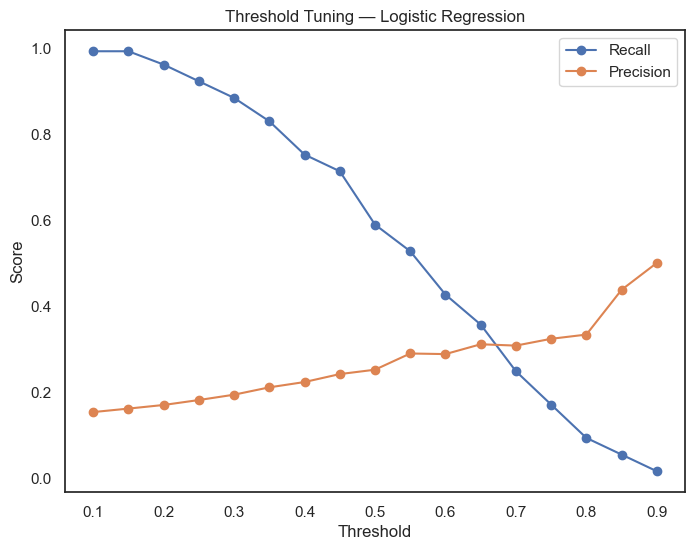

In [109]:

plt.figure(figsize=(8,6))
plt.plot(thresh_df["threshold"], thresh_df["recall"], marker="o", label="Recall")
plt.plot(thresh_df["threshold"], thresh_df["precision"], marker="o", label="Precision")
plt.title(f"Threshold Tuning — {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()



# Feature Importance

We compute **Permutation Importance** (model-agnostic).  
This estimates how much ROC-AUC drops when each feature is randomly shuffled.


In [110]:

def get_feature_names_from_column_transformer(ct):
    feature_names = []
    for name, transformer, cols in ct.transformers_:
        if name == "remainder" and transformer == "drop":
            continue
        if transformer is None:
            continue
        if hasattr(transformer, "named_steps"):
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]
                feature_names.extend(list(ohe.get_feature_names_out(cols)))
            else:
                feature_names.extend(cols)
        else:
            if hasattr(transformer, "get_feature_names_out"):
                feature_names.extend(list(transformer.get_feature_names_out(cols)))
            else:
                feature_names.extend(cols)
    return np.array(feature_names)

feature_names = get_feature_names_from_column_transformer(preprocessor)
len(feature_names), feature_names[:10]


(27,
 array(['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
        'male_0', 'male_1', 'education_1.0'], dtype='<U23'))

In [111]:

best_model_name = results_df.iloc[0]["Model"]
best_pipe = pipelines[best_model_name]

# Extract the preprocessor and the final model from the best pipeline
preprocessor_step = best_pipe.named_steps['preprocess']
model_step = best_pipe.named_steps['model']

# Transform X_test using the preprocessor to get the features that the model actually sees
X_test_processed = preprocessor_step.transform(X_test)

r = permutation_importance(
    model_step, X_test_processed, y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1
)

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

perm_imp.head(20)


,feature,importance_mean,importance_std
0,age,0.079860,0.016243
8,male_1,0.012951,0.005017
2,sysBP,0.012599,0.007255
26,smoke_category_None,0.012133,0.003761
23,smoke_category_Heavy,0.006447,0.002921
25,smoke_category_Moderate,0.005362,0.002065
20,prevalentHyp_1,0.003790,0.002875
7,male_0,0.002639,0.001433
22,diabetes_1,0.002625,0.002173
14,currentSmoker_1,0.001520,0.001005


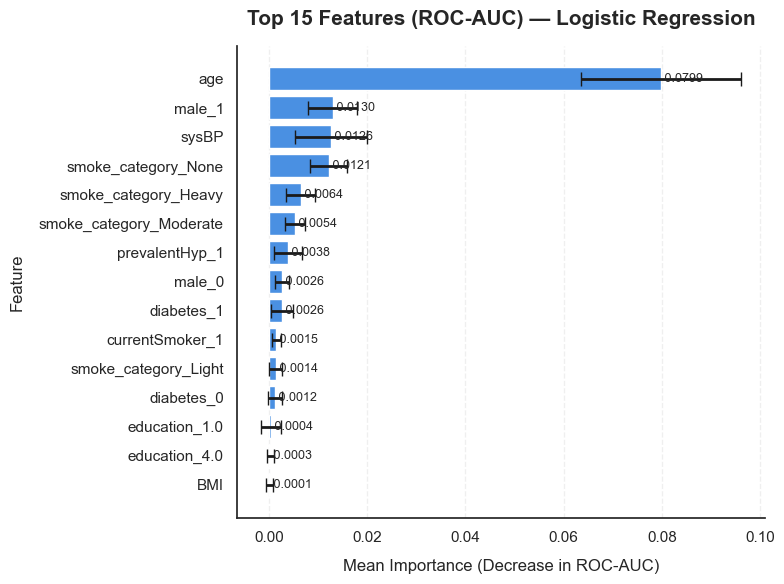

In [112]:
sns.set_theme(style="white")
top_n = 15
top = perm_imp.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top["feature"], top["importance_mean"], 
               xerr=top["importance_std"], 
               color='#4A90E2',
               error_kw={'elinewidth': 2, 'capsize': 5})

ax.set_xlabel("Mean Importance (Decrease in ROC-AUC)", fontsize=12, labelpad=10)
ax.set_ylabel("Feature", fontsize=12, labelpad=10)
ax.set_title(f"Top {top_n} Features (ROC-AUC) — {best_model_name}", 
             fontsize=15, fontweight='bold', pad=15)

# Add grid for readability (matching the whitegrid style)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on the bars
for i, (feat, val) in enumerate(zip(top["feature"], top["importance_mean"])):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=9)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()